In [2]:
!pip install xgboost

In [4]:
import random

SEED = 10000000 # could change to other seed
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

from sklearn.metrics import roc_auc_score, roc_curve, auc, classification_report

from xgboost import XGBClassifier

# bigger plot
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['axes.grid'] = True

In [6]:
# step 1. Read data and initial review

data_path = "musicData.csv"   
df = pd.read_csv(data_path)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nGenre counts:")
print(df["music_genre"].value_counts())
df.head()


Shape: (50005, 18)

Columns: ['instance_id', 'artist_name', 'track_name', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'obtained_date', 'valence', 'music_genre']

Genre counts:
music_genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64


,instance_id,artist_name,track_name,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,obtained_date,valence,music_genre
0,32894.0,Röyksopp,Röyksopp's Night Out,27.0,0.00468,0.652,-1.0,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,4-Apr,0.759,Electronic
1,46652.0,Thievery Corporation,The Shining Path,31.0,0.01270,0.622,218293.0,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.00200000000001,4-Apr,0.531,Electronic
2,30097.0,Dillon Francis,Hurricane,28.0,0.00306,0.620,215613.0,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,4-Apr,0.333,Electronic
3,62177.0,Dubloadz,Nitro,34.0,0.02540,0.774,166875.0,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,4-Apr,0.270,Electronic
4,24907.0,What So Not,Divide & Conquer,32.0,0.00465,0.638,222369.0,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,4-Apr,0.323,Electronic


In [8]:

# step 2. Data preprocessing and feature engineering

df_proc = df.copy()

duration_median = df_proc.loc[df_proc["duration_ms"] > 0, "duration_ms"].median()
df_proc.loc[df_proc["duration_ms"] < 0, "duration_ms"] = duration_median

df_proc["mode_encoded"] = df_proc["mode"].map({"Major": 1, "Minor": 0})

mode_median = int(df_proc["mode_encoded"].median())
df_proc["mode_encoded"] = df_proc["mode_encoded"].fillna(mode_median)

key_le = LabelEncoder()
df_proc["key_encoded"] = key_le.fit_transform(df_proc["key"].astype(str))

drop_cols = [
    "instance_id",
    "artist_name",
    "track_name",
    "obtained_date",
    "key",
    "mode"
]
df_proc = df_proc.drop(columns=drop_cols)

df_proc.head()


,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,music_genre,mode_encoded,key_encoded
0,27.0,0.00468,0.652,227360.0,0.941,0.79200,0.115,-5.201,0.0748,100.889,0.759,Electronic,0.0,1
1,31.0,0.01270,0.622,218293.0,0.890,0.95000,0.124,-7.043,0.0300,115.00200000000001,0.531,Electronic,0.0,5
2,28.0,0.00306,0.620,215613.0,0.755,0.01180,0.534,-4.617,0.0345,127.994,0.333,Electronic,1.0,11
3,34.0,0.02540,0.774,166875.0,0.700,0.00253,0.157,-4.498,0.2390,128.014,0.270,Electronic,1.0,4
4,32.0,0.00465,0.638,222369.0,0.587,0.90900,0.157,-6.266,0.0413,145.036,0.323,Electronic,1.0,9


In [10]:

# step 2.2 Uniformly handle ‘?’ as NaN and convert to numeric values.


df_proc = df_proc.replace('?', np.nan)

# make numeric
for col in df_proc.columns:
    if col != "music_genre":
        df_proc[col] = pd.to_numeric(df_proc[col], errors='coerce')

# use median value
numeric_cols = [c for c in df_proc.columns if c != "music_genre"]
for col in numeric_cols:
    median_val = df_proc[col].median() 
    df_proc[col] = df_proc[col].fillna(median_val)

print(df_proc.dtypes)


popularity          float64
acousticness        float64
danceability        float64
duration_ms         float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
music_genre          object
mode_encoded        float64
key_encoded           int64
dtype: object


In [12]:
# step 2.3

df_proc = df_proc.dropna(subset=["music_genre"])

df_proc["music_genre"] = df_proc["music_genre"].astype(str)

print("After dropping NaN genres:")

print(df_proc["music_genre"].value_counts())

print("Unique genres:", df_proc["music_genre"].unique())

df_proc = df_proc.reset_index(drop=True)


After dropping NaN genres:
music_genre
Electronic     5000
Anime          5000
Jazz           5000
Alternative    5000
Country        5000
Rap            5000
Blues          5000
Rock           5000
Classical      5000
Hip-Hop        5000
Name: count, dtype: int64
Unique genres: ['Electronic' 'Anime' 'Jazz' 'Alternative' 'Country' 'Rap' 'Blues' 'Rock'
 'Classical' 'Hip-Hop']


In [14]:

# step 3. Define the feature matrix X and the target y


genre_col = "music_genre"

feature_cols = [c for c in df_proc.columns if c != genre_col]

X_all = df_proc[feature_cols].values
y_str_all = df_proc[genre_col].values

print("X shape:", X_all.shape)
print("y (string) shape:", y_str_all.shape)


genre_le = LabelEncoder()
y_all = genre_le.fit_transform(y_str_all)
num_classes = len(genre_le.classes_)

print("Number of classes:", num_classes)
print("Classes:", genre_le.classes_)


X shape: (50000, 13)
y (string) shape: (50000,)
Number of classes: 10
Classes: ['Alternative' 'Anime' 'Blues' 'Classical' 'Country' 'Electronic'
 'Hip-Hop' 'Jazz' 'Rap' 'Rock']


In [16]:

# step 4. Perform train/test split by genre
# Select 500 test samples per genre; the remainder are used for training


def stratified_split_per_genre(df_with_genre, genre_col="music_genre",
                               test_per_genre=500, random_state=SEED):
    train_idx = []
    test_idx = []
    rng = np.random.RandomState(random_state)

    for genre, group in df_with_genre.groupby(genre_col):
        idx = group.index.values
      
        rng.shuffle(idx)
        
        test_size = min(test_per_genre, len(idx))
        test_idx.extend(idx[:test_size])
        train_idx.extend(idx[test_size:])

    return np.array(train_idx), np.array(test_idx)


train_idx, test_idx = stratified_split_per_genre(df_proc, genre_col, test_per_genre=500, random_state=SEED)

X_train = X_all[train_idx]
X_test = X_all[test_idx]

y_train_str = y_str_all[train_idx]
y_test_str = y_str_all[test_idx]

y_train = genre_le.transform(y_train_str)
y_test = genre_le.transform(y_test_str)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 45000
Test size: 5000


In [18]:

# step 5. Dimension reduction: StandardScaler + PCA
#(Performed before training; model trained using reduced dimension features)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA method to 10 d
n_components = 10
pca = PCA(n_components=n_components, random_state=SEED)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"PCA n_components = {n_components}")
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", sum(pca.explained_variance_ratio_))
print("X_train_pca shape:", X_train_pca.shape)
print("X_test_pca shape:", X_test_pca.shape)

PCA n_components = 10
Explained variance ratio: [0.28481924 0.1039561  0.08463145 0.07945826 0.07521235 0.07347471
 0.0727836  0.06230881 0.05409904 0.04563157]
Total explained variance: 0.9363751312144837
X_train_pca shape: (45000, 10)
X_test_pca shape: (5000, 10)


In [20]:

# step 6. Training a Multi-Class classification model using XGBoost
# (Features after PCA dimension reduction)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report

xgb_clf = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1
)


xgb_clf.fit(X_train_pca, y_train)


y_proba_test = xgb_clf.predict_proba(X_test_pca)
y_pred_test = np.argmax(y_proba_test, axis=1)

print("Classification report (on test set):")
print(classification_report(y_test, y_pred_test, target_names=genre_le.classes_))



Classification report (on test set):
              precision    recall  f1-score   support

 Alternative       0.40      0.36      0.38       500
       Anime       0.71      0.64      0.67       500
       Blues       0.50      0.46      0.48       500
   Classical       0.82      0.83      0.83       500
     Country       0.44      0.50      0.47       500
  Electronic       0.57      0.55      0.56       500
     Hip-Hop       0.35      0.37      0.36       500
        Jazz       0.48      0.45      0.47       500
         Rap       0.31      0.30      0.31       500
        Rock       0.45      0.53      0.49       500

    accuracy                           0.50      5000
   macro avg       0.50      0.50      0.50      5000
weighted avg       0.50      0.50      0.50      5000



Macro-averaged AUC (OvR): 0.9043


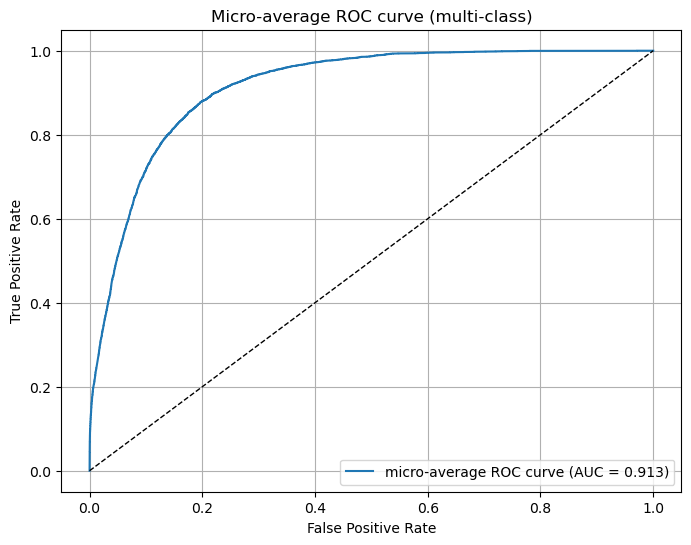

In [22]:

# step 7. Calculate Multi-Class AUC and plot ROC curve

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, roc_curve, auc

y_test_bin = label_binarize(y_test, classes=np.arange(num_classes))

# Macro AUC 
macro_auc = roc_auc_score(y_test_bin, y_proba_test, average="macro", multi_class="ovr")

print(f"Macro-averaged AUC (OvR): {macro_auc:.4f}")

# Micro average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), y_proba_test.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)

plt.figure()
plt.plot(fpr_micro, tpr_micro, label=f"micro-average ROC curve (AUC = {roc_auc_micro:.3f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Micro-average ROC curve (multi-class)")
plt.legend(loc="lower right")
plt.show()

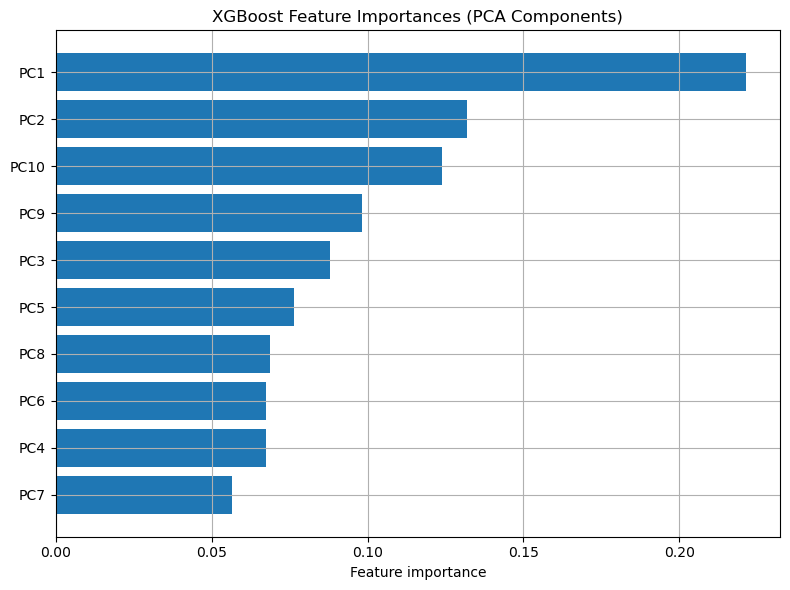


PCA Components Original Feature Weights:
PC1: loudness(0.457) energy(0.438) acousticness(-0.423) 
PC2: danceability(0.457) popularity(0.371) tempo(-0.345) 
PC3: mode_encoded(0.647) speechiness(-0.420) key_encoded(0.409) 
PC4: liveness(0.568) key_encoded(0.476) speechiness(0.455) 
PC5: duration_ms(0.532) key_encoded(0.464) liveness(-0.442) 


In [28]:

# step 8. Feature importance visualization（XGBoost on PCA components）

importances = xgb_clf.feature_importances_
pca_feature_names = [f"PC{i+1}" for i in range(n_components)]

indices = np.argsort(importances)[::-1]
top_n = min(10, n_components)
top_features = [pca_feature_names[i] for i in indices[:top_n]]
top_importances = importances[indices[:top_n]]

plt.figure(figsize=(8, 6))
plt.barh(range(top_n), top_importances[::-1])
plt.yticks(range(top_n), top_features[::-1])
plt.xlabel("Feature importance")
plt.title("XGBoost Feature Importances (PCA Components)")
plt.tight_layout()
plt.show()


print("\nPCA Components Original Feature Weights:")

for i in range(min(5, n_components)):
    component = pca.components_[i]
    top_idx = np.argsort(np.abs(component))[::-1][:3]
    
    print(f"PC{i+1}: ", end="")
    
    for idx in top_idx:
        print(f"{feature_cols[idx]}({component[idx]:.3f})", end=" ")
    print()



/var/folders/y4/nbqvyw6n1b5c6dgpmjz2q2vh0000gn/T/ipykernel_25833/136992122.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(genres))


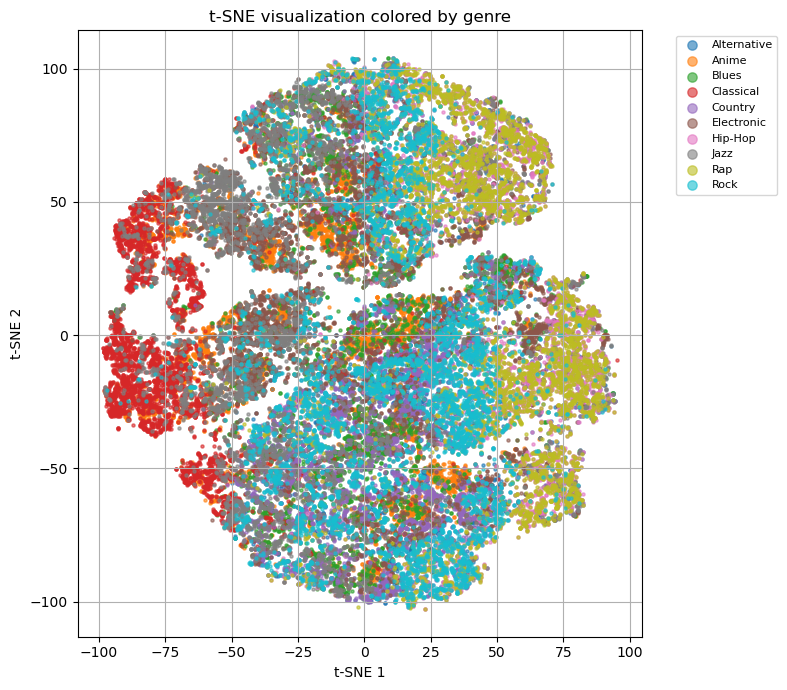

In [26]:

# step 9. t-SNE Visualization

from sklearn.manifold import TSNE

# StandardScaler + PCA + t-SNE
X_all_scaled = scaler.fit_transform(X_all)
X_all_pca = pca.fit_transform(X_all_scaled)

tsne = TSNE(
    n_components=2,
    random_state=SEED,
    perplexity=40,
    init="pca",
    learning_rate="auto"
)
X_tsne = tsne.fit_transform(X_all_pca)

df_viz = pd.DataFrame({
    "tsne_1": X_tsne[:, 0],
    "tsne_2": X_tsne[:, 1],
    "music_genre": y_str_all
})

# color by genre for visual
genres = sorted(df_viz["music_genre"].unique())
colors = plt.cm.get_cmap("tab10", len(genres))

plt.figure(figsize=(8, 7))

for i, g in enumerate(genres):
    subset = df_viz[df_viz["music_genre"] == g]
    plt.scatter(subset["tsne_1"], subset["tsne_2"],
                s=5, alpha=0.6, label=g, c=[colors(i)])
    
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE visualization colored by genre")
plt.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

/var/folders/y4/nbqvyw6n1b5c6dgpmjz2q2vh0000gn/T/ipykernel_25833/1700290605.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cluster_colors = plt.cm.get_cmap("tab10", num_classes)


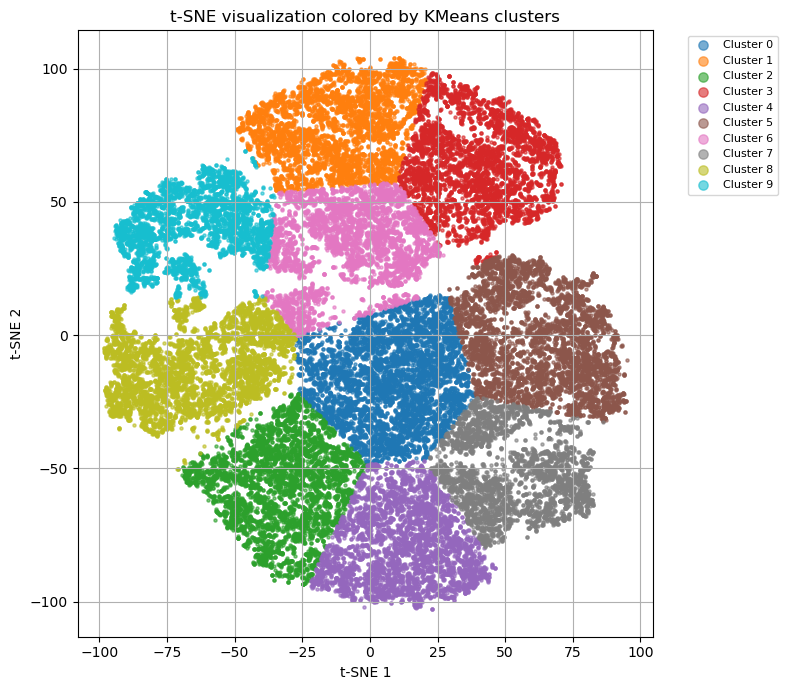

cluster         0    1     2     3     4     5    6    7     8     9
music_genre                                                         
Alternative   944  757   421   465   624   557  592  427   130    83
Anime         948  397   273    43   516   147  950  319   777   630
Blues        1017  753   878    79   664   478  602  155   269   105
Classical      85  144   680     6    48    32  112   14  2461  1418
Country      1264  318  1078   155  1126   419  196  433     9     2
Electronic    522  523    77   345   278   504  943  213   860   735
Hip-Hop       144  375    97  1701   241  1451  139  824    12    16
Jazz          263  846   887   237   206   184  344  116   887  1030
Rap           208  373   111  1662   296  1351  193  780    12    14
Rock          970  579   632   331   790   533  415  566   124    60


In [30]:

# step 10. KMeans Cluster

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=num_classes, random_state=SEED)

clusters = kmeans.fit_predict(X_tsne)
df_viz["cluster"] = clusters

plt.figure(figsize=(8, 7))
cluster_colors = plt.cm.get_cmap("tab10", num_classes)

for c in range(num_classes):
    subset = df_viz[df_viz["cluster"] == c]
    plt.scatter(subset["tsne_1"], subset["tsne_2"],
                s=5, alpha=0.6, label=f"Cluster {c}", c=[cluster_colors(c)])
    
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.title("t-SNE visualization colored by KMeans clusters")
plt.legend(markerscale=3, fontsize=8, bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# cluster vs genre 
ct = pd.crosstab(df_viz["music_genre"], df_viz["cluster"])
print(ct)
